# Tutorial: Load a Trained Network and Evaluate

Shows how to reload a model trained by `closure-train fit` and:

1. **Quick path** — Use `RunLoader` (3 lines for metrics + plots)
2. **Manual path** — Step-by-step reconstruction for full control

In [ ]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from closure import ClosureDataModule, ClosureLitModule, MLP, RunLoader, load_paths
import closure.evaluation as ev
from closure.visualization import plot_pred_targets

---
## Quick path: `RunLoader`

`RunLoader` reconstructs the model, data module, and test dataset from a single
Lightning `version_*` directory.  Metrics and plots are one-liners.

In [ ]:
import os

# The config uses ./ relative paths that resolve against CWD.
project_root = Path(__file__).resolve().parents[2] if '__file__' in dir() else Path('..', '..').resolve()
os.chdir(project_root)
print('CWD set to:', Path.cwd())

paths = load_paths(str(project_root / 'paths.yaml'))

# Point to the Lightning version directory (adjust as needed)
version_dir = Path(paths['work_dir']) / 'Lightning/Harris/Le/lightning_logs/version_0'
print('version_dir:', version_dir)

CWD set to: /volume1/scratch/georgem/closure
run_dir    : /volume1/scratch/georgem/closure/models/tuto
config_path: /volume1/scratch/georgem/closure/models/tuto/configs/mlp.yaml
ckpt_dir   : /volume1/scratch/georgem/closure/models/tuto/checkpoints


Load everything with one call:

In [ ]:
run = RunLoader.from_version_dir(version_dir)
run

DataModule and network created from config.
Architecture: [10, 60, 80, 50, 40, 6]


Regression metrics (one line):

In [ ]:
display(run.metrics())

Loading checkpoint: /volume1/scratch/georgem/closure/models/tuto/checkpoints/epochepoch=002-vallossval_loss=0.6396.ckpt
Model loaded and set to eval mode.


Plot a single target (one line):

In [ ]:
run.plot('Pxx_e', robust_quantile=0.995, error_mode='relative')

Failed to read Pxy_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pxy_0'
Off-diagonal pressure Pxy_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pxz_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pxz_0'
Off-diagonal pressure Pxz_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pyz_0 from T2D13_tiny/T2D-Fields_003000.h5.pkl using path /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny: 'Pyz_0'
Off-diagonal pressure Pyz_0 absent for species 'e'. Filling with zeros (shape (128, 128, 1)). If this field should be present, check your simulation output.
Failed to read Pxy_0 from T2D13_tiny/T2D-Fields_003500.h5.pkl using path /volume1/scratch/georgem/closure/

test samples: 32768
test features shape: (32768, 10)
test targets shape : (32768, 6)
target channels    : ['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e']


Plot all targets at once:

In [ ]:
run.plot_all(signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

prediction   shape: (32768, 6)
ground_truth shape: (32768, 6)


You still have full access to the underlying objects:

```python
run.model       # ClosureLitModule (eval mode)
run.datamodule  # ClosureDataModule (setup done)
run.dataset     # test DataFrameDataset
run.config      # raw YAML dict
```

In [ ]:
# Use run.predict() and run.dataset for custom analyses
gt, pred = run.predict()

channels = run.dataset.request_targets
n_ch = len(channels)
metrics_df = run.metrics(ground_truth=gt, prediction=pred)

fig, axes = plt.subplots(1, n_ch, figsize=(4 * n_ch, 4), squeeze=False)
for idx, ch_name in enumerate(channels):
    ax = axes[0, idx]
    y = gt[:, idx].ravel()
    yhat = pred[:, idx].ravel()
    ax.scatter(y, yhat, s=1, alpha=0.3)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, 'r--', linewidth=0.8, label='1:1')
    ax.set_xlabel('ground truth')
    ax.set_ylabel('predicted')
    r2 = metrics_df.loc[metrics_df.channel == ch_name, 'r2'].values[0]
    ax.set_title(f'{ch_name}  ($R^2$={r2:.3f})')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
5,5,Pyz_e,0.773127,0.879276,0.562915,0.752206,0.888433,1.378861,0.637683
1,1,Pyy_e,3.000484,1.732190,1.472301,0.668690,0.900256,3.114464,0.556176
2,2,Pzz_e,2.563498,1.601093,1.326005,0.445074,0.854446,2.144733,0.746523
3,3,Pxy_e,0.109883,0.331486,0.254844,0.421637,0.768669,0.781054,0.424409
4,4,Pxz_e,6.695322,2.587532,1.072971,0.419861,0.742967,2.037702,1.269828
0,0,Pxx_e,3.642872,1.908631,1.714654,0.307368,0.930784,2.954658,0.645974


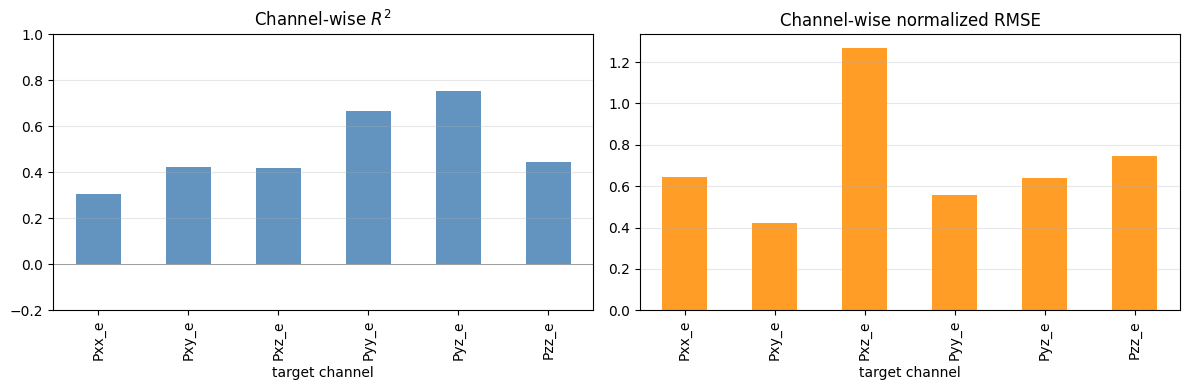

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms = metrics_df.set_index('channel').sort_index()

ms['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

ms['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')

plt.tight_layout()
plt.show()

---
## Manual path (for reference)

If you need full control, the objects inside `RunLoader` are the same
`ClosureDataModule`, `ClosureLitModule`, and `DataFrameDataset` as before.
You can also construct a `RunLoader` from a config + checkpoint directly:

In [ ]:
# Equivalent to RunLoader.from_version_dir but with explicit paths:
config_path = version_dir / 'config.yaml'
ckpt_path = next((version_dir / 'checkpoints').glob('*.ckpt'))

run_manual = RunLoader.from_config(config_path, ckpt_path)
print('Model:', run_manual.model)
print('Test dataset size:', len(run_manual.dataset))
print('Targets:', run_manual.dataset.request_targets)

Plotting timestep indices: [0, 1]
Resolved data folder     : /volume1/scratch/georgem/closure/tests/fixtures/ecsim_tiny


invfunc = <ufunc 'exp'>


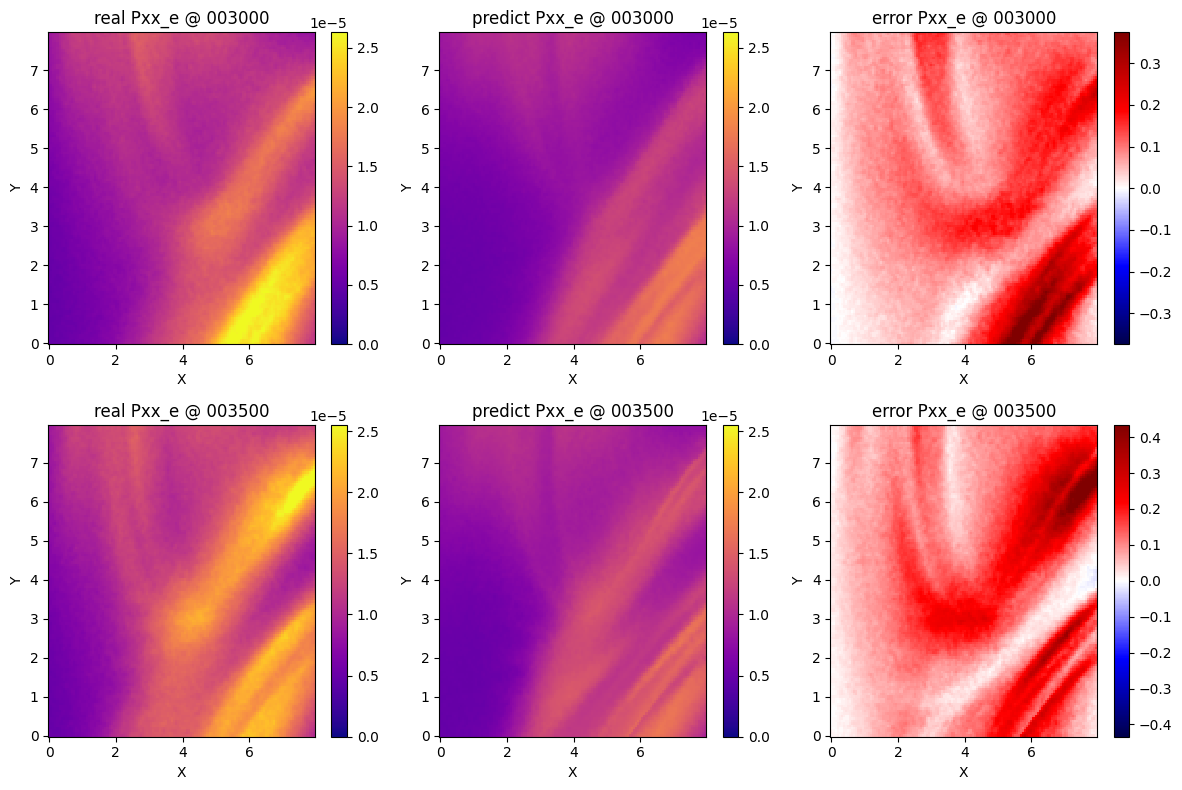

In [ ]:
# Or access default ev.transform_targets directly:
gt_manual, pred_manual = ev.transform_targets(
    run_manual.model,
    run_manual.dataset,
    target_channels=run_manual.target_channels,
    rescale=False,
    renorm=False,
    verbose=False,
)
print('shapes:', gt_manual.shape, pred_manual.shape)